# Lecture 9 – Classifiers: Data Preparation, Logistic Regression & Evaluation

**Goal:** predict a recipe's national cuisine (Chinese, Indian, Japanese, Korean, Thai) from its list of ingredients.

In this lecture you will:
1. Explore and clean the cuisine dataset
2. Split the data correctly into training and test sets
3. Train a **logistic regression** classifier
4. Evaluate it with a **confusion matrix**, **precision / recall / F1**, and **ROC curves**
5. Learn how to handle **class imbalance**

## 0. Setup

You need the packages `pandas`, `matplotlib`, `scikit-learn` and `imbalanced-learn`.

Put `cuisines.csv` in the same folder as this notebook.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42   # fixed seed

## 1. Load and inspect the data

In [24]:
cuisines = pd.read_csv('cuisines.csv')
cuisines = cuisines.drop(columns=['Unnamed: 0'])   # the old index column from the original file
cuisines.head()

,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,indian,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [25]:
cuisines.info()

<class 'pandas.DataFrame'>
RangeIndex: 2448 entries, 0 to 2447
Columns: 384 entries, cuisine to zucchini
dtypes: int64(383), str(1)
memory usage: 7.2 MB


`cuisine` is categorical column (text) → **target** (label). (Scikit-learn accepts text labels directly and encodes them internally)

The other 383 columns are multi-hot encoded (0/1) → **features**: 1 means the ingredient is in the recipe, 0 means it is not.

In [26]:
ingredients_per_recipe = cuisines.drop(columns='cuisine').sum(axis=1)
ingredients_per_recipe.describe()

count    2448.000000
mean        9.656863
std         4.206256
min         1.000000
25%         7.000000
50%         9.000000
75%        13.000000
max        25.000000
dtype: float64

A typical recipe uses about 9–10 ingredients out of 383 possible ones, so the data is very **sparse** (mostly zeros).

## 2. How many recipes per cuisine?

cuisine
korean      799
indian      598
chinese     442
japanese    320
thai        289
Name: count, dtype: int64


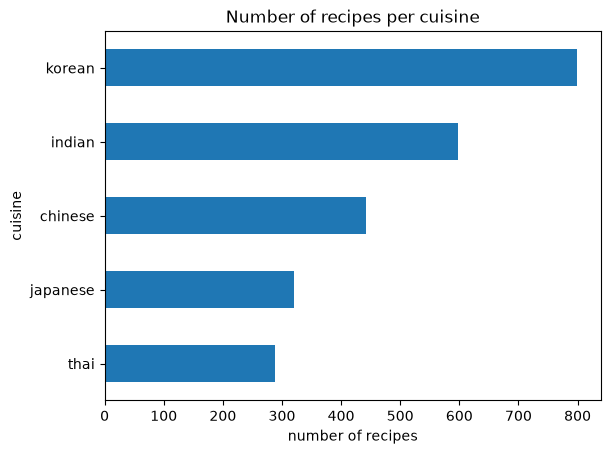

In [27]:
counts = cuisines['cuisine'].value_counts()
print(counts)
counts.sort_values().plot.barh(title='Number of recipes per cuisine')
plt.xlabel('number of recipes')
plt.show()

The classes are **imbalanced**: there are almost three times as many Korean recipes as Thai ones.
A model can get a decent accuracy just by favouring the big classes. We come back to this in section 9.

## 3. Most common ingredients per cuisine

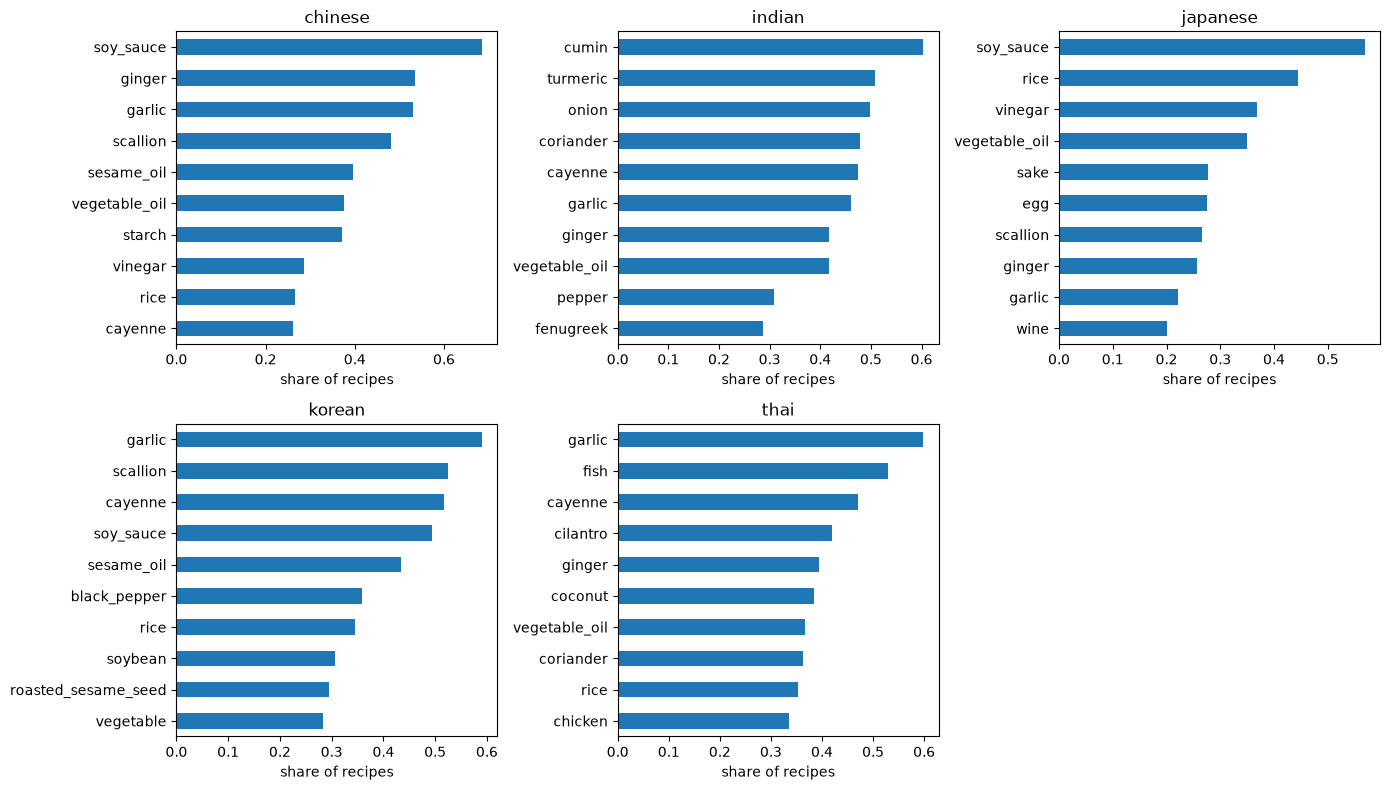

In [28]:
def top_ingredients(df, n=10):
    """Return the n most frequent ingredients in df, as a fraction of recipes."""
    usage = df.drop(columns='cuisine').mean()   # mean of a 0/1 column = share of recipes that use it
    return usage.sort_values(ascending=False).head(n)

cuisine_names = sorted(cuisines['cuisine'].unique())
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, name in zip(axes.flat, cuisine_names):
    top = top_ingredients(cuisines[cuisines['cuisine'] == name])
    top.sort_values().plot.barh(ax=ax, title=name)
    ax.set_xlabel('share of recipes')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

## 4. Cleaning

### 4a. Ingredients that never appear

In [29]:
features = cuisines.drop(columns='cuisine')
unused = features.columns[features.sum() == 0]
print(f'{len(unused)} ingredients never appear in any recipe, e.g. {list(unused[:5])}')
cuisines = cuisines.drop(columns=unused)
print('New shape:', cuisines.shape)

99 ingredients never appear in any recipe, e.g. ['angelica', 'apple_brandy', 'armagnac', 'artichoke', 'baked_potato']
New shape: (2448, 285)


A column that is always 0 carries no information, so we remove it.

### 4b. Duplicate recipes

In [30]:
n_dup = cuisines.duplicated().sum()
print(f'{n_dup} exact duplicate rows')

# Same ingredients, but labelled with different cuisines?
ingredient_cols = cuisines.columns.drop('cuisine')
conflicts = (cuisines.groupby(list(ingredient_cols))['cuisine'].nunique() > 1).sum()
print(f'{conflicts} ingredient lists appear with more than one cuisine label')

cuisines = cuisines.drop_duplicates().reset_index(drop=True)
print('Shape after removing duplicates:', cuisines.shape)

31 exact duplicate rows
11 ingredient lists appear with more than one cuisine label
Shape after removing duplicates: (2417, 285)


<span style="color:red;"><b>Question:</b> Why do duplicates matter, beyond wasting space?</span>

<span style="color:green;"><b>Answer:</b></span><br>
Duplicates don't just take up space: they change what the model learns and how we judge it. Here are the four main problems.

- **Inflated test score:** if the same recipe ends up in both the training set and the test set, the model is tested on something it has already seen. It can get that recipe right from memory rather than from patterns it has learned, so the test score looks better than the model really is. This is a simple form of **data leakage**, and it gives us false confidence in how well the model handles new recipes.

- **Extra weight:** every row counts once during training, so a recipe that appears 5 times counts 5 times as much as a recipe that appears once. The model then leans towards those repeated ingredient combinations, even though they are no more important than any other recipe. In effect, the duplicates quietly act like hidden class weights that nobody chose.

- **Skewed class balance:** if one cuisine has more duplicates than the others, it looks bigger than it really is. That changes the class balance the model sees and the numbers we use to decide whether, and how much, to balance the classes. Methods like SMOTE or `class_weight='balanced'` would then correct for an imbalance that is partly fake.

- **Conflicting labels:** we only record *which* ingredients a recipe contains, so two different dishes can end up with exactly the same row of 0s and 1s. If one is labelled Chinese and the other Korean, the model sees identical inputs with different answers, and no model can get both right. These cases set an upper limit on the best possible accuracy, which is why we count them in the cell above.

### 4c. Should we drop very common ingredients?

A popular idea is to remove ingredients that appear in many recipes (for example garlic or ginger), on the assumption that they don't help tell cuisines apart.
Let's check that assumption instead of trusting it.

In [31]:
overall = cuisines.drop(columns='cuisine').mean().sort_values(ascending=False)
common = overall[overall >= 0.30].index
print('Ingredients used in at least 30% of all recipes:', list(common))

usage_by_cuisine = cuisines.groupby('cuisine')[list(common)].mean().round(2)
usage_by_cuisine

Ingredients used in at least 30% of all recipes: ['garlic', 'cayenne', 'soy_sauce', 'ginger', 'vegetable_oil', 'scallion']


,garlic,cayenne,soy_sauce,ginger,vegetable_oil,scallion
cuisine,,,,,,
chinese,0.53,0.26,0.69,0.54,0.38,0.49
indian,0.47,0.48,0.01,0.42,0.42,0.06
japanese,0.23,0.08,0.58,0.26,0.36,0.27
korean,0.59,0.52,0.49,0.28,0.27,0.53
thai,0.60,0.47,0.32,0.40,0.37,0.31


<span style="color:red;"><b>Question:</b> Look at the table. Is `soy_sauce` useless for telling cuisines apart?</span>

<span style="color:green;"><b>Answer:</b></span><br>
No. Soy sauce is in about 69% of Chinese recipes but only about 1% of Indian ones. An ingredient can be common **overall** and still be very **discriminative** between classes.
What matters is how much its usage differs *between* cuisines, not how often it appears in total.

So we **keep** these ingredients.

### 4d. Save the cleaned data

In [32]:
cuisines.to_csv('cleaned_cuisines.csv', index=False)
print('Saved cleaned_cuisines.csv with shape', cuisines.shape)

Saved cleaned_cuisines.csv with shape (2417, 285)


Note: we do **not** balance the classes (e.g. with SMOTE) before saving. Balancing must happen *after* the train/test split, and only on the training data.

## 5. Features, labels and the train/test split

In [33]:
X = cuisines.drop(columns='cuisine')
y = cuisines['cuisine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

print('Training set:', X_train.shape, ' Test set:', X_test.shape)
print('\nShare of each cuisine (train vs test):')
print(pd.DataFrame({'train': y_train.value_counts(normalize=True),
                    'test':  y_test.value_counts(normalize=True)}).round(3))

Training set: (1691, 284)  Test set: (726, 284)

Share of each cuisine (train vs test):
          train   test
cuisine               
korean    0.324  0.325
indian    0.245  0.245
chinese   0.182  0.182
japanese  0.130  0.129
thai      0.119  0.118


`test_size=0.3` keeps 30% of recipes aside to test the model on data it has never seen.

`stratify=y` keeps the same share of each cuisine in both sets.

`random_state` makes the split reproducible: everyone in class gets the same split.

**Golden rule:** split *first*. Anything that learns from the data (scaling, feature selection, oversampling, the model itself) must be fitted on the training set only.

## 6. A baseline: how good is "always guess the biggest class"?

In [34]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
print('Baseline accuracy:', round(baseline.score(X_test, y_test), 3))

Baseline accuracy: 0.325


Any real model has to beat this number to be worth anything.

## 7. Logistic regression

Logistic regression learns one weight per ingredient for each cuisine and turns the weighted sum into a probability.
With more than two classes, scikit-learn handles the multiclass case automatically (multinomial / softmax), so we don't need any special setting.

In [35]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, y_pred), 3))

Test accuracy: 0.807


### Look at one prediction

In [36]:
i = 50
recipe = X_test.iloc[[i]]
print('Ingredients:', list(recipe.columns[recipe.iloc[0] == 1]))
print('True cuisine:', y_test.iloc[i])

proba = pd.Series(model.predict_proba(recipe)[0], index=model.classes_)
proba.sort_values(ascending=False).round(3)

Ingredients: ['beef', 'sake', 'scallion', 'soy_sauce', 'vegetable_oil', 'wine']
True cuisine: japanese


japanese    0.948
korean      0.031
chinese     0.020
thai        0.001
indian      0.000
dtype: float64

`predict_proba` gives a probability for every cuisine. `predict` simply picks the highest one.

## 8. Evaluating the model

### 8a. Confusion matrix

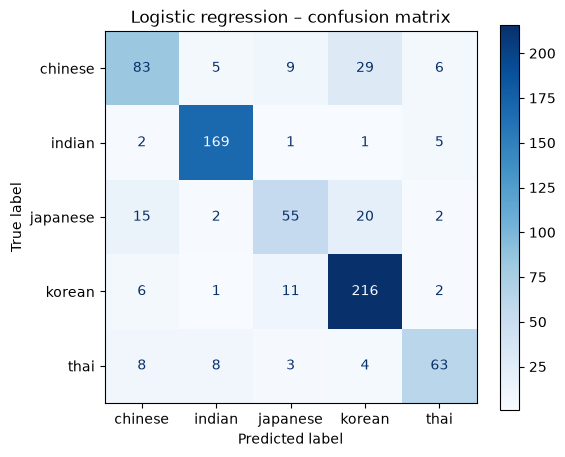

In [37]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Logistic regression – confusion matrix')
plt.show()

⚠️ **Read the axes carefully.** In scikit-learn, **rows are the actual (true) classes** and **columns are the predicted classes**.

<span style="color:red;"><b>Question:</b> Which two cuisines does the model confuse the most?</span>

<span style="color:green;"><b>Answer:</b></span><br>
Find the largest number outside the diagonal: the row is the true cuisine, the column what the model predicted instead. With our split, the biggest mistake is **Chinese recipes predicted as Korean** (29), followed by Japanese predicted as Korean. Recall the ingredient plots: these cuisines share soy sauce, scallion, garlic and sesame oil.

### 8b. Precision, recall and F1 per cuisine

In [38]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

     chinese      0.728     0.629     0.675       132
      indian      0.914     0.949     0.931       178
    japanese      0.696     0.585     0.636        94
      korean      0.800     0.915     0.854       236
        thai      0.808     0.733     0.768        86

    accuracy                          0.807       726
   macro avg      0.789     0.762     0.773       726
weighted avg      0.802     0.807     0.802       726



- **Precision** for Thai: of all recipes the model *called* Thai, how many really were Thai?
- **Recall** for Thai: of all *real* Thai recipes, how many did the model find?
- **F1**: the harmonic mean of the two.
- **support**: how many test recipes of that cuisine there are.

The last rows combine the per-class scores:
- **macro avg**: simple average over the classes — every cuisine counts equally.
- **weighted avg**: average weighted by support — big cuisines count more.
- **micro avg** isn't printed, because for single-label multiclass problems it is exactly equal to accuracy. Let's check:

In [39]:
for avg in ['micro', 'macro', 'weighted']:
    print(f"{avg:>8}:  precision={precision_score(y_test, y_pred, average=avg):.3f}  "
          f"recall={recall_score(y_test, y_pred, average=avg):.3f}  "
          f"f1={f1_score(y_test, y_pred, average=avg):.3f}")
print(f"accuracy:  {accuracy_score(y_test, y_pred):.3f}")

   micro:  precision=0.807  recall=0.807  f1=0.807
   macro:  precision=0.789  recall=0.762  f1=0.773
weighted:  precision=0.802  recall=0.807  f1=0.802
accuracy:  0.807


### 8c. ROC curves (one-vs-rest)

A ROC curve needs **scores or probabilities**, not hard predictions: it moves a threshold from 0 to 1 and plots the true-positive rate against the false-positive rate.
ROC is defined for two classes, so for five cuisines we draw one curve per cuisine: *this cuisine* vs *all the others* (one-vs-rest).

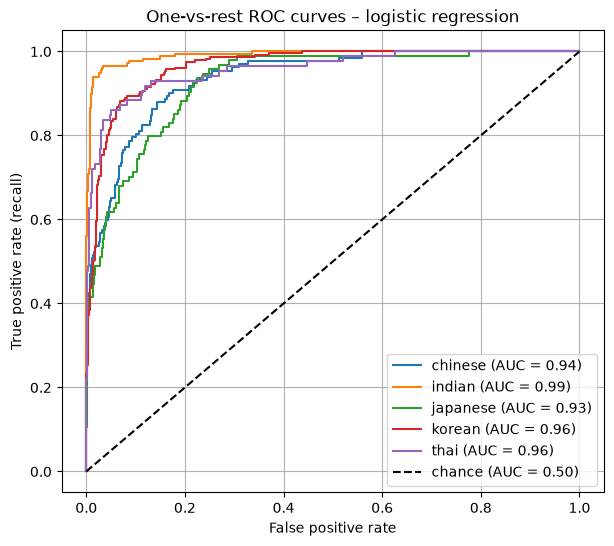

Macro-average one-vs-rest AUC: 0.956


In [40]:
classes = model.classes_
y_test_bin = np.asarray(label_binarize(y_test, classes=classes))   # one 0/1 column per cuisine
y_score = model.predict_proba(X_test)                  # one probability column per cuisine

plt.figure(figsize=(7, 6))
for k, name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, k], y_score[:, k])
    auc_k = roc_auc_score(y_test_bin[:, k], y_score[:, k])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_k:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='chance (AUC = 0.50)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (recall)')
plt.title('One-vs-rest ROC curves – logistic regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print('Macro-average one-vs-rest AUC:', round(roc_auc_score(y_test, y_score, multi_class='ovr'), 3))

An AUC of 1.0 is a perfect ranking, 0.5 is guessing. An AUC far *below* 0.5 usually means the labels are flipped somewhere: inverting the predictions would give a good model.

## 9. Handling class imbalance

Options to stop the model from favouring the big classes:
1. **Do nothing** and check per-class recall.
2. **Class weights:** tell the model that mistakes on small classes cost more (`class_weight='balanced'`).
3. **Oversampling** the small classes in the training data:
   - `RandomOverSampler` copies existing minority recipes.
   - **SMOTE** creates *new synthetic* recipes by interpolating between neighbours.

### 9a. Class weights

Normally every training recipe counts the same when the model learns. With imbalanced classes, the model can lower its total error most easily by getting the big cuisines right, so the small ones get less attention.

**Class weights** change how much each mistake costs. With `class_weight='balanced'`, scikit-learn gives every cuisine the weight

$$\text{weight}_c = \frac{\text{number of training recipes}}{\text{number of cuisines} \times \text{number of training recipes of cuisine } c}$$

so a cuisine with half as many recipes gets twice the weight. Let's look at the weights for our training set:

In [41]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

weight_table = pd.DataFrame({'training recipes': y_train.value_counts().reindex(classes),
                             'weight': weights}, index=classes)
weight_table['recipes × weight'] = weight_table['training recipes'] * weight_table['weight']
weight_table.round(2)

,training recipes,weight,recipes × weight
chinese,307,1.10,338.2
indian,415,0.81,338.2
japanese,220,1.54,338.2
korean,548,0.62,338.2
thai,201,1.68,338.2


The last column shows the idea: after weighting, **every cuisine contributes the same total amount** to the training error, no matter how many recipes it has.

Using it is a single argument. No new data is created and no extra library is needed:

In [42]:
weighted_model = LogisticRegression(max_iter=1000, class_weight='balanced')
weighted_model.fit(X_train, y_train)

recall_compare = pd.DataFrame({
    'no weights':     recall_score(y_test, y_pred, average=None, labels=classes),
    'class weights':  recall_score(y_test, weighted_model.predict(X_test), average=None, labels=classes),
}, index=classes)
recall_compare['change'] = recall_compare['class weights'] - recall_compare['no weights']
print('Recall per cuisine on the test set:')
recall_compare.round(3)

Recall per cuisine on the test set:


,no weights,class weights,change
chinese,0.629,0.682,0.053
indian,0.949,0.944,-0.006
japanese,0.585,0.649,0.064
korean,0.915,0.822,-0.093
thai,0.733,0.767,0.035


With class weights, the smaller cuisines are found more often: Japanese (+0.06), Chinese (+0.05) and Thai (+0.03).
Korean, the biggest cuisine with the smallest weight (0.62), pays for it: its recall drops by about 0.09, because the model no longer falls back on "Korean" as readily.
Indian hardly changes, since its recipes were already easy to recognise.

As section 9c shows, overall accuracy and macro F1 barely move. Class weights mainly change *which* cuisines the model gets right.

### 9b. Oversampling

Two common mistakes with oversampling:
- **Oversampling before the split.** Synthetic test recipes are then built from training recipes, and the test set no longer looks like real data. The score becomes too optimistic. Always split first and oversample **only the training set**. An `imblearn` **Pipeline** does this automatically.
- **Using plain SMOTE on 0/1 data.** SMOTE interpolates (e.g. 0.4 of an ingredient), which makes no sense for yes/no features. Let's see what happens:

In [43]:
from imblearn.over_sampling import SMOTE, SMOTEN, RandomOverSampler
from imblearn.pipeline import make_pipeline

X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
synthetic = X_res.iloc[len(X_train):]          # the new rows SMOTE added

print('Average ingredients per real recipe:     ', round(X_train.sum(axis=1).mean(), 2))
print('Average ingredients per SMOTE recipe:    ', round(synthetic.sum(axis=1).mean(), 2))
print('Values in synthetic data:', np.unique(synthetic.values))

Average ingredients per real recipe:      9.8
Average ingredients per SMOTE recipe:     4.87
Values in synthetic data: [0 1]


Because the columns are integers, the interpolated values are cut back to 0 or 1, and the synthetic recipes end up with far fewer ingredients than real ones — they are not realistic recipes.
For categorical / binary features, imbalanced-learn provides **SMOTEN**, which builds synthetic samples by majority vote of the neighbours instead.

### 9c. Comparing the options

Now let's compare the options fairly, all trained on the same training set and tested on the same untouched test set:

In [44]:
candidates = {
    'no balancing':          LogisticRegression(max_iter=1000),
    'class_weight=balanced': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomOverSampler':     make_pipeline(RandomOverSampler(random_state=RANDOM_STATE),
                                           LogisticRegression(max_iter=1000)),
    'SMOTEN':                make_pipeline(SMOTEN(random_state=RANDOM_STATE),
                                           LogisticRegression(max_iter=1000)),
}

rows = []
for name, clf in candidates.items():
    clf.fit(X_train, y_train)               # oversampling (if any) happens only on X_train
    pred = clf.predict(X_test)
    rows.append({'method': name,
                 'accuracy': accuracy_score(y_test, pred),
                 'macro F1': f1_score(y_test, pred, average='macro'),
                 **{f'recall {c}': r for c, r in zip(sorted(y.unique()),
                                                     recall_score(y_test, pred, average=None))}})
imbalance_results = pd.DataFrame(rows).set_index('method').round(3)
imbalance_results

,accuracy,macro F1,recall chinese,recall indian,recall japanese,recall korean,recall thai
method,,,,,,,
no balancing,0.807,0.773,0.629,0.949,0.585,0.915,0.733
class_weight=balanced,0.798,0.771,0.682,0.944,0.649,0.822,0.767
RandomOverSampler,0.800,0.772,0.659,0.938,0.628,0.843,0.802
SMOTEN,0.785,0.756,0.674,0.921,0.606,0.822,0.767


<span style="color:red;"><b>Question:</b> Class weights and oversampling both try to balance the classes. What is the advantage of class weights for our data?</span>

<span style="color:green;"><b>Answer:</b></span><br>
Class weights and oversampling aim for the same thing: making the small cuisines count as much as the big ones during training. The difference is *how*. Oversampling changes the data, while class weights leave the data alone and only change how much each mistake costs. For our recipe data, that brings four advantages.

- **The data stays real:** RandomOverSampler adds exact copies of existing recipes, and SMOTE / SMOTEN build artificial recipes that may not be realistic (fractional ingredients, or too few ingredients). With class weights, the model only ever trains on the real recipes we collected. What it learns is therefore based on actual dishes, not on data we invented to fill a gap.

- **Same idea, no copies:** giving a cuisine a weight of 2 has the same effect as including each of its recipes twice, because every mistake on that cuisine now counts double. For logistic regression the two are mathematically identical. The difference is that no duplicate rows exist, so none of the duplicate problems from section 4b can come back.

- **No leakage risk:** oversampling has to be done carefully, after the split and only on the training data, or copies of recipes end up on both sides. Class weights don't create or move any rows, so there is nothing that could leak into the test set or into the validation folds during cross-validation. The weights are calculated from `y_train` alone, so they also follow the golden rule automatically.

- **Simple:** it's a single argument, `class_weight='balanced'`, with no extra library and no pipeline needed. Many scikit-learn models support it, including logistic regression, SVMs, random forests and gradient boosting. That makes it a good first thing to try before reaching for more complex methods.

<span style="color:red;"><b>Question:</b> Which model is the best, and why do some cuisines have low recall and others high?</span>

<span style="color:green;"><b>Answer:</b></span><br>
**Class weights** (`class_weight='balanced'`), although it is not a clear-cut decision: on the overall scores, all options except SMOTEN are practically tied. The choice depends on what we care about.

**Why some cuisines have low recall.** Two things decide how easy a cuisine is for the model: how many examples it has and how distinctive its ingredients are.
Korean is the biggest class, so when the model is unsure it tends to fall back on "Korean", which gives Korean a high recall (0.915).
Japanese and Chinese are smaller and share many ingredients with Korean (soy sauce, sesame oil, scallion), so they are often predicted as Korean and get low recall (0.585 and 0.629).
Indian is only mid-sized but has very distinctive ingredients (cumin, turmeric), so it is easy to recognise (0.949).
So low recall comes from being small *and* similar to a bigger cuisine.

**What balancing does.** All three balancing methods make the model pay more attention to the small cuisines. You can see the effect in every row: Chinese, Japanese and Thai recall go up, while Korean recall goes down.
The model stops defaulting to Korean, so it finds more of the smaller cuisines but misses some Korean recipes it used to get right. Indian stays about the same, because it was already easy to recognise.

**The cost: accuracy drops slightly.** Accuracy counts every test recipe equally, and Korean is the biggest group in the test set. Losing some Korean recipes therefore costs more in accuracy than the smaller cuisines gain.
That's why accuracy falls from 0.807 to about 0.80 for class weights and RandomOverSampler, even though three cuisines improved and Indian stayed about the same.
**Macro F1** gives every cuisine equal weight, and it barely moves (0.773 without balancing, 0.771 with class weights, 0.772 with RandomOverSampler): the gains on the small cuisines and the loss on Korean roughly cancel out.

**Why SMOTEN is the weakest.** SMOTEN trains on artificial recipes that have fewer ingredients than real ones. These unrealistic examples add noise, so it drops on both accuracy (0.785) and macro F1 (0.756).

**Why class weights are the best choice.** Class weights are essentially tied with no balancing on macro F1 (0.771 vs. 0.773), but they find noticeably more of the small cuisines: Japanese goes from 0.585 to 0.649, Chinese from 0.629 to 0.682 and Thai from 0.733 to 0.767. Every cuisine gets recognised more fairly, at almost no cost overall.
They are as good as or better than SMOTEN on every measure, and RandomOverSampler gives similar results only by copying recipes. Class weights are also the simplest option: one argument, no extra library, no artificial data and no leakage risk. The cross-validation in Lecture 2 confirms this, with class weights slightly ahead of no balancing on macro F1 and balanced accuracy.

**When not to balance.** If the only goal is the highest overall accuracy, no balancing is fine. Keep in mind that these numbers come from a single test split, so differences of 0.01–0.02 can partly be luck.

<span style="color:red;"><b>Question:</b>Why is the recall score for Chinese and Japanese low compared to other cuisines?</span>



<span style="color:green;"><b>Answer:</b></span><br>
Mostly because Chinese and Japanese recipes look a lot like Korean ones, and Korean is the biggest cuisine in the data.<br>

Looking back at the plots earlier, the three East Asian cuisines share many of their most common ingredients: soy sauce, garlic, scallion, sesame oil.<br>
So for a lot of recipes, the ingredients alone don't make it obvious which of the three it is.<br>
When the model is unsure, it leans towards Korean, simply because it has seen far more Korean recipes (548, compared with 307 Chinese and 220 Japanese). And, you can see this in the confusion matrix: the most common mistakes are Chinese and Japanese recipes predicted as Korean.<br>

So it is not just about size. Thai is the smallest cuisine, but it still does better (0.733) than Chinese (0.629) and Japanese (0.585), because ingredients like fish sauce and lemongrass make Thai recipes easy to spot.<br>
Indian does even better (0.949) thanks to ingredients like cumin and turmeric.<br>
So what really hurts a cuisine is being *similar* to a bigger one.<br>

Balancing the classes helps a little, because the model stops defaulting to Korean so often. But the ingredients still overlap, so these two cuisines remain the hardest to tell apart.

### What we learn
- Balancing does not make the model better overall here: accuracy and macro F1 stay about the same (plain SMOTEN is even a bit worse).
- What balancing *does* is shift recall **between** cuisines: the smaller cuisines (Chinese, Japanese, Thai) are found more often, at the cost of Korean recall.
- So the right choice depends on the goal. If missing a small cuisine is costly, use balancing — and the simplest option, `class_weight='balanced'`, works as well as oversampling without any extra library.
- Fancy is not automatically better: always compare against the simple option on an honest test set.

## 10. Summary

- Clean the data: drop empty columns and duplicates; don't drop features just because they are common.
- **Split first** (stratified, with a fixed `random_state`), then fit everything on the training set only.
- Compare against a **baseline**.
- Accuracy is not enough: look at the **confusion matrix** and per-class **precision / recall / F1**, and at macro vs weighted averages.
- ROC/AUC needs probabilities; for multiclass use one-vs-rest.
- Imbalance: try `class_weight='balanced'` first. It reweights mistakes instead of changing the data, so every cuisine counts equally in training. If you oversample, do it inside a pipeline and use SMOTEN for binary features.

## Exercises
1. Drop the "common" ingredients from section 4c from `X_train` and `X_test`, retrain the logistic regression and compare accuracy and macro F1.
2. Change `test_size` to 0.2 and `random_state` to another number. How much does the accuracy move? What does that tell you about trusting a single split?
3. Try `LogisticRegression(C=0.1, max_iter=1000)` and `C=10`. `C` controls regularisation: smaller `C` = simpler model. What happens?
4. Pick a cuisine with low recall and print a few of its misclassified recipes. Do the mistakes make sense to you?
5. Class weights don't have to be `'balanced'`. Pass your own dictionary, e.g. `class_weight={'japanese': 2}` (cuisines you leave out keep weight 1). Can you raise Japanese recall without lowering macro F1?